# ResNet50 Baseline No Fourier — FIXED Test Evaluation

Javított baseline test-evaluation notebook.

Fontos javítás:
- a modell classifier része pontosan ugyanaz, mint a tanításnál,
- checkpoint local `/content` alá másolva töltődik be,
- `strict=True`, hogy ne adjon hamis eredményt részleges betöltéssel.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.10.0+cu128


In [3]:
# =========================
# PATHOK ÉS BEÁLLÍTÁSOK
# =========================

RESNET_CKPT = "/content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/best_resnet50_baseline.pth"

TEST_DIR = "/content/drive/MyDrive/Brain MRI/dataset/Test"

OUT_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 2

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
label_map = {c: i for i, c in enumerate(CLASS_NAMES)}
label_map_inv = {i: c for c, i in label_map.items()}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Checkpoint exists:", os.path.exists(RESNET_CKPT))
print("Test exists:", os.path.exists(TEST_DIR))
print("Output:", OUT_DIR)

if not os.path.exists(RESNET_CKPT):
    raise FileNotFoundError(RESNET_CKPT)

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(TEST_DIR)

Checkpoint exists: True
Test exists: True
Output: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED


In [4]:
# =========================
# TEST FÁJLOK BEOLVASÁSA
# =========================

def normalize_folder_name(name):
    s = name.lower().strip().replace("-", "_").replace(" ", "_")
    if "glioma" in s:
        return "glioma"
    if "meningioma" in s:
        return "meningioma"
    if "pituitary" in s:
        return "pituitary"
    if s in ["no_tumor", "notumor", "no_tumour", "notumour", "normal", "healthy"]:
        return "no_tumor"
    if "no" in s and ("tumor" in s or "tumour" in s):
        return "no_tumor"
    return s

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

rows = []

print("Test mappa tartalma:")
for folder in sorted(os.listdir(TEST_DIR)):
    folder_path = os.path.join(TEST_DIR, folder)
    if not os.path.isdir(folder_path):
        continue

    label = normalize_folder_name(folder)

    n_imgs = len([f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)])
    print(f"{folder:25s} -> {label:12s} -> {n_imgs} kép")

    if label not in label_map:
        print("Kihagyva:", folder)
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(valid_exts):
            rows.append({
                "image_path": os.path.join(folder_path, fname),
                "folder_label": folder,
                "label": label,
                "label_idx": label_map[label]
            })

df_test = pd.DataFrame(rows)

if len(df_test) == 0:
    raise RuntimeError("Nem találtam képeket a test mappában.")

print("\nÖsszes test kép:", len(df_test))
display(df_test["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame("count"))

file_list_path = os.path.join(OUT_DIR, "test_file_list.csv")
df_test.to_csv(file_list_path, index=False)
print("Mentve:", file_list_path)

Test mappa tartalma:
glioma                    -> glioma       -> 603 kép
meningioma                -> meningioma   -> 436 kép
notumor                   -> no_tumor     -> 389 kép
pituitary                 -> pituitary    -> 429 kép

Összes test kép: 1857


,count
label,
glioma,603
meningioma,436
no_tumor,389
pituitary,429


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/test_file_list.csv


In [5]:
# =========================
# DATASET ÉS DATALOADER
# =========================

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_idx"])

        if self.transform:
            image = self.transform(image)

        return image, label, row["image_path"]

test_dataset = BrainTumorDataset(df_test, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Dataset:", len(test_dataset))
print("Batches:", len(test_loader))

Dataset: 1857
Batches: 233


In [6]:
# =========================
# MODELL: ResNet50 baseline - JAVÍTOTT
# Pontosan mint a tanításnál:
# model.fc = Sequential(Dropout(0.30), Linear(...))
# =========================

model = models.resnet50(weights=None)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, len(CLASS_NAMES))
)
model = model.to(device)

print(model.fc)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)


In [7]:
# =========================
# CHECKPOINT BETÖLTÉS - JAVÍTOTT
# =========================
# Drive hiba ellen először local /content alá másoljuk.
# strict=True: ha nem pontos az architektúra, azonnal hibát dob.

LOCAL_CKPT = "/content/best_resnet50_baseline.pth"
shutil.copy2(RESNET_CKPT, LOCAL_CKPT)

try:
    ckpt = torch.load(LOCAL_CKPT, map_location=device, weights_only=True)
except TypeError:
    ckpt = torch.load(LOCAL_CKPT, map_location=device)
except Exception:
    ckpt = torch.load(LOCAL_CKPT, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

state = {k.replace("module.", ""): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model = model.to(device)
model.eval()

print("Checkpoint sikeresen betöltve strict=True módban.")
print("Local checkpoint:", LOCAL_CKPT)

Checkpoint sikeresen betöltve strict=True módban.
Local checkpoint: /content/best_resnet50_baseline.pth


In [8]:
# =========================
# TEST KIÉRTÉKELÉS
# =========================

y_true = []
y_pred = []
y_prob = []
paths = []

use_amp = torch.cuda.is_available()

with torch.no_grad():
    for images, labels, image_paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())
        paths.extend(list(image_paths))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predikciók elkészültek.")
print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

Testing:   0%|          | 0/233 [00:00<?, ?it/s]

Predikciók elkészültek.
y_true: (1857,)
y_pred: (1857,)
y_prob: (1857, 4)


In [9]:
# =========================
# SUMMARY METRICS
# =========================

acc = accuracy_score(y_true, y_pred)

summary_df = pd.DataFrame([{
    "Model": "ResNet50 Baseline No Fourier",
    "Test Accuracy": acc,
    "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Number of test images": len(y_true)
}])

display(summary_df)

summary_path = os.path.join(OUT_DIR, "test_summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)
print("Mentve:", summary_path)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Number of test images
0,ResNet50 Baseline No Fourier,0.929456,0.9294,0.936276,0.93111,0.932872,0.929456,0.929247,1857


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/test_summary_metrics.csv


In [10]:
# =========================
# CLASSIFICATION REPORT
# =========================

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(report_df)

report_path = os.path.join(OUT_DIR, "classification_report.csv")
report_df.to_csv(report_path)
print("Mentve:", report_path)

,precision,recall,f1-score,support
glioma,0.975655,0.864013,0.916447,603.000000
meningioma,0.878981,0.949541,0.912900,436.000000
no_tumor,0.960630,0.940874,0.950649,389.000000
pituitary,0.902335,0.990676,0.944444,429.000000
accuracy,0.929456,0.929456,0.929456,0.929456
macro avg,0.929400,0.936276,0.931110,1857.000000
weighted avg,0.932872,0.929456,0.929247,1857.000000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/classification_report.csv


In [11]:
# =========================
# PAPER-READY METRIKA TÁBLÁZAT
# =========================

prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    zero_division=0
)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "ResNet50 Baseline No Fourier",
        "Class": cls,
        "Precision": round(float(prec[i]), 4),
        "Recall": round(float(rec[i]), 4),
        "F1-Score": round(float(f1[i]), 4),
        "Support": int(support[i]),
        "Accuracy": ""
    })

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": ""
})

rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": round(float(acc), 4)
})

results_table_df = pd.DataFrame(rows)
display(results_table_df)

results_path = os.path.join(OUT_DIR, "test_results_table.csv")
results_table_df.to_csv(results_path, index=False)
print("Mentve:", results_path)

,Model,Class,Precision,Recall,F1-Score,Support,Accuracy
0,ResNet50 Baseline No Fourier,glioma,0.9757,0.8640,0.9164,603,
1,ResNet50 Baseline No Fourier,meningioma,0.8790,0.9495,0.9129,436,
2,ResNet50 Baseline No Fourier,no_tumor,0.9606,0.9409,0.9506,389,
3,ResNet50 Baseline No Fourier,pituitary,0.9023,0.9907,0.9444,429,
4,,Macro Avg,0.9294,0.9363,0.9311,1857,
5,,Weighted Avg,0.9329,0.9295,0.9292,1857,0.9295


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/test_results_table.csv


,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,521,41,12,29
True: meningioma,3,414,3,16
True: no_tumor,10,12,366,1
True: pituitary,0,4,0,425


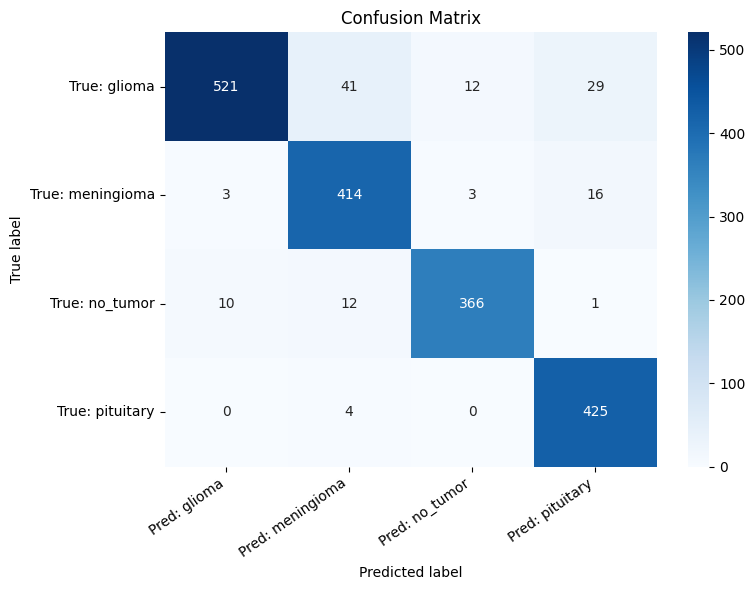

CSV: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/confusion_matrix_counts.csv
PNG: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/confusion_matrix.png


In [12]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_df)

cm_csv = os.path.join(OUT_DIR, "confusion_matrix_counts.csv")
cm_df.to_csv(cm_csv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_png = os.path.join(OUT_DIR, "confusion_matrix.png")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV:", cm_csv)
print("PNG:", cm_png)

,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,0.864013,0.067993,0.019900,0.048093
True: meningioma,0.006881,0.949541,0.006881,0.036697
True: no_tumor,0.025707,0.030848,0.940874,0.002571
True: pituitary,0.000000,0.009324,0.000000,0.990676


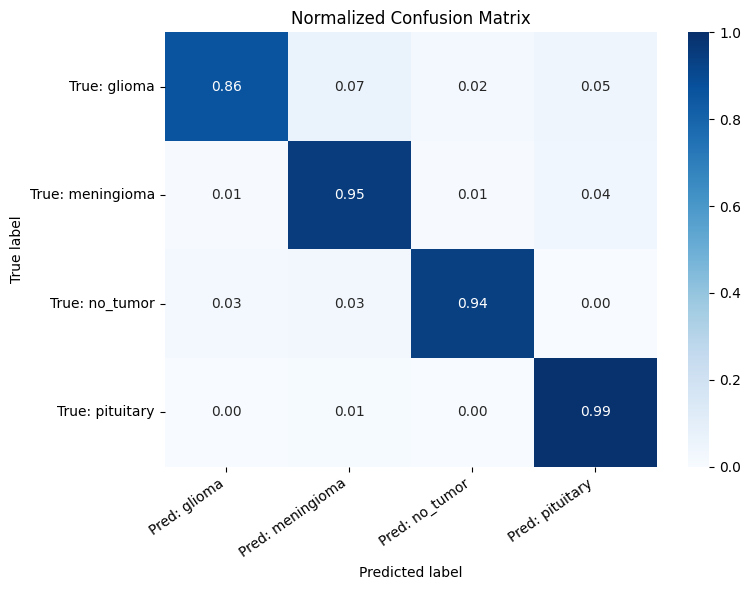

CSV: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/confusion_matrix_normalized.csv
PNG: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/normalized_confusion_matrix.png


In [13]:
# =========================
# NORMALIZED CONFUSION MATRIX
# =========================

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_norm_df)

cm_norm_csv = os.path.join(OUT_DIR, "confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_csv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=True, vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_png = os.path.join(OUT_DIR, "normalized_confusion_matrix.png")
plt.savefig(cm_norm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV:", cm_norm_csv)
print("PNG:", cm_norm_png)

In [14]:
# =========================
# PER-IMAGE PREDICTIONS + MISCLASSIFIED
# =========================

pred_rows = []

for i in range(len(y_true)):
    row = {
        "image_path": paths[i],
        "true_idx": int(y_true[i]),
        "pred_idx": int(y_pred[i]),
        "true_label": label_map_inv[int(y_true[i])],
        "predicted_label": label_map_inv[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "confidence": float(np.max(y_prob[i]))
    }

    for j, cname in enumerate(CLASS_NAMES):
        row[f"prob_{cname}"] = float(y_prob[i][j])

    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)
display(pred_df.head(20))

pred_path = os.path.join(OUT_DIR, "per_image_predictions.csv")
pred_df.to_csv(pred_path, index=False)
print("Mentve:", pred_path)

wrong_df = pred_df[pred_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(50))

wrong_path = os.path.join(OUT_DIR, "misclassified.csv")
wrong_df.to_csv(wrong_path, index=False)
print("Mentve:", wrong_path)

,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
0,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000033,0.000032,0.000048
1,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000011,0.000058,0.000012
2,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000018,0.000065,0.000063
3,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000008,0.000052,0.000027
4,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000036,0.000189,0.000078
5,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000006,0.000009,0.000029
6,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000004,0.000008,0.000012
7,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000054,0.000240,0.000177
8,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.875488,0.875488,0.119202,0.001648,0.003483
9,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000006,0.000057,0.000069


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/per_image_predictions.csv


,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
1291,/content/drive/MyDrive/Brain MRI/dataset/Test/...,2,1,no_tumor,meningioma,False,0.999512,0.000291,0.999512,0.000113,0.000025
486,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999512,0.000404,0.999512,0.000162,0.000114
523,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999512,0.000035,0.999512,0.000014,0.000314
421,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.999023,0.000569,0.000214,0.999023,0.000056
439,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,3,glioma,pituitary,False,0.999023,0.000847,0.000007,0.000040,0.999023
559,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.998535,0.000014,0.000629,0.998535,0.000793
555,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.998535,0.000117,0.000677,0.998535,0.000668
755,/content/drive/MyDrive/Brain MRI/dataset/Test/...,1,3,meningioma,pituitary,False,0.998535,0.000156,0.001224,0.000269,0.998535
518,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998535,0.000905,0.998535,0.000185,0.000473
519,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998047,0.000835,0.998047,0.000047,0.001256


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/misclassified.csv


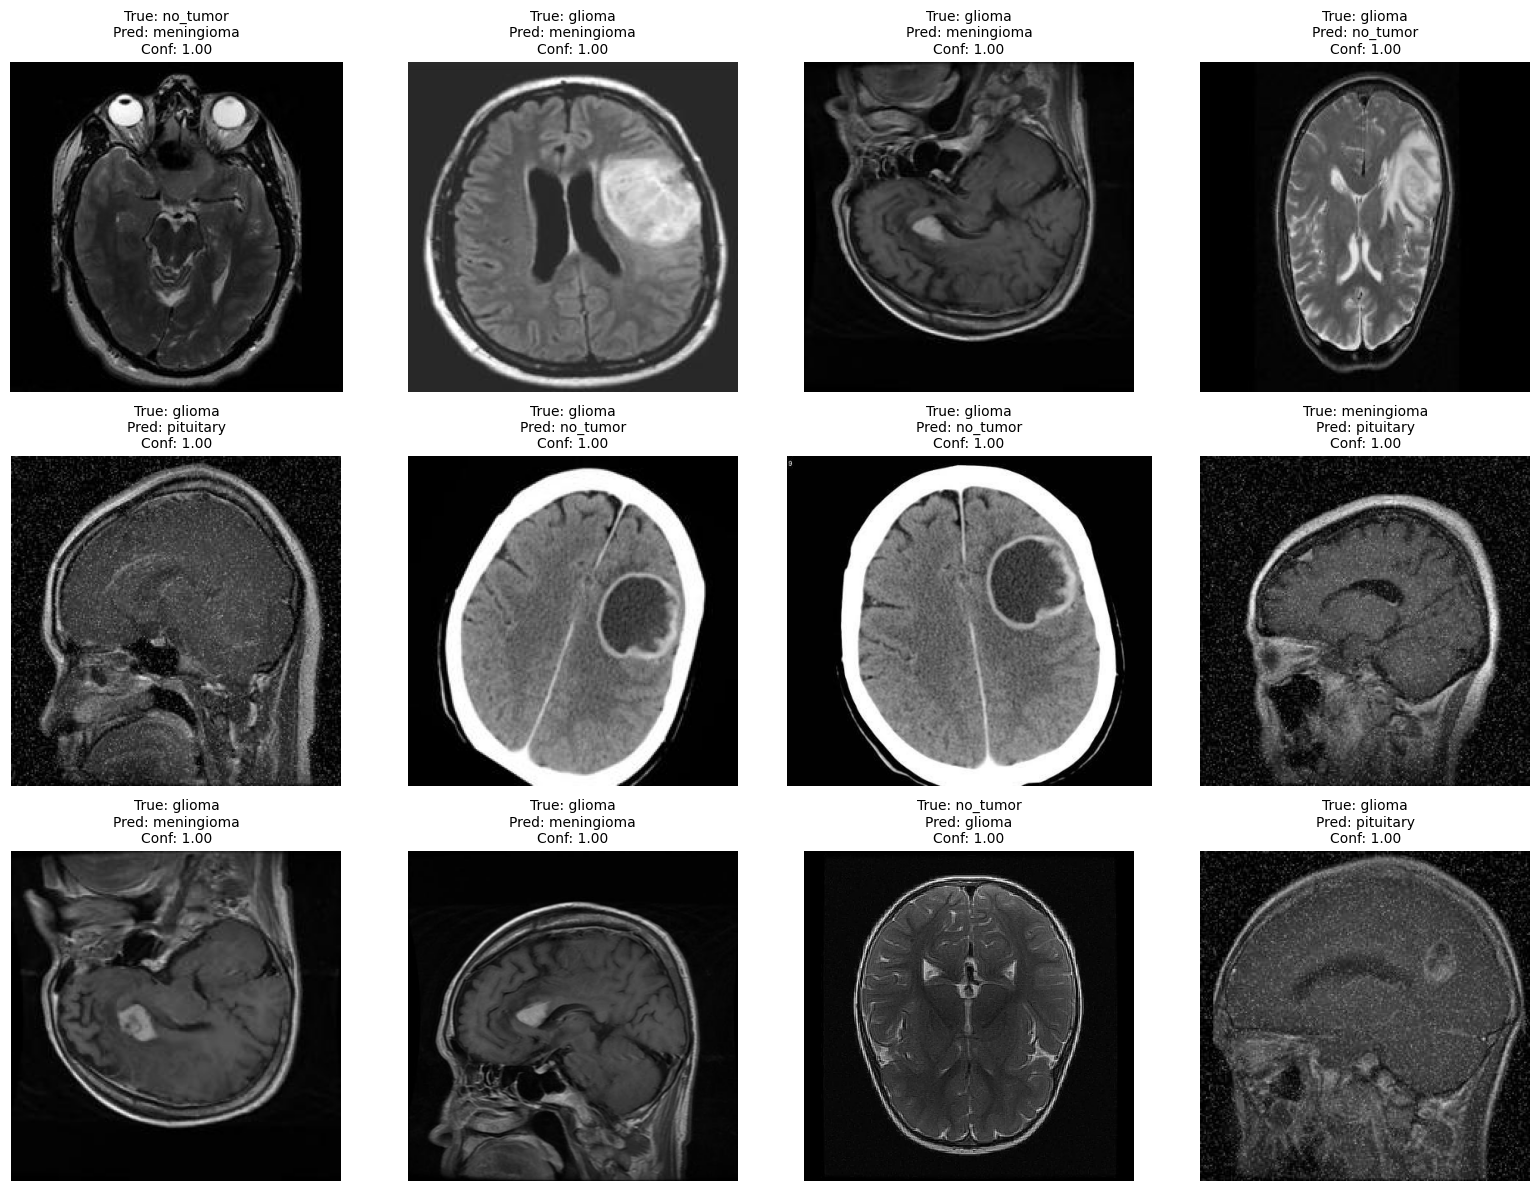

Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED/misclassified_examples.png


In [15]:
# =========================
# MISCLASSIFIED EXAMPLES
# =========================

def show_misclassified_examples(wrong_df, max_images=12):
    if len(wrong_df) == 0:
        print("Nincs hibás klasszifikáció.")
        return

    sample_df = wrong_df.head(max_images)
    n = len(sample_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "misclassified_examples.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Mentve:", out_path)

show_misclassified_examples(wrong_df)

In [16]:
print("Kész.")
print("Eredmények:", OUT_DIR)
print("\nFájlok:")
for f in sorted(os.listdir(OUT_DIR)):
    print("-", f)

Kész.
Eredmények: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/resnet50_test_evaluation_FIXED

Fájlok:
- classification_report.csv
- confusion_matrix.png
- confusion_matrix_counts.csv
- confusion_matrix_normalized.csv
- misclassified.csv
- misclassified_examples.png
- normalized_confusion_matrix.png
- per_image_predictions.csv
- test_file_list.csv
- test_results_table.csv
- test_summary_metrics.csv
